In [12]:
from scipy.io import loadmat
import numpy as np
from numpy import *
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import pickle
from control import lqr, ss
from control.matlab import lsim
import random
from tqdm import tqdm
import os

**The Tabular value-fucntion methods on the cart and pole system**

Consider the cart-and-pole system here depicted:
<div>
<img src="https://drive.google.com/uc?export=view&id=1Yu5zZ57OEEYZ678yWLaU7h-Wq3M9vV9E" width="200">
</div>
whose dynamics follows the following equations:

\begin{align}
  \ddot{\theta}&=\frac{g \sin(\theta)\,+\,\cos(\theta) \left[ \frac{-F\,-\,m_p\,l\,\dot{\theta}^2 \sin \left(\theta\right)}{m_c\,+\,m_p}\right]-\frac{\mu_p\dot{\theta}}{m_p\,l}}{l\,\left[\frac{4}{3}-\frac{m_p\,cos^2\left(\theta\right)}{m_c\,+\,m_p}\right]}
\end{align}
>>>>>>>>>>>>>>>>>>>>>>>>$(*)$

\begin{align}
  \ddot{p}_c&=\frac{F\,+\,m_p\,l\,\left[\dot{\theta}^2\,\sin\left(\theta\right)\,-\,\ddot{\theta}\,\cos(\theta)\right]}{m_c\,+\,m_p}
\end{align}

where $g = 9.8\,\text{m/sec}$ is the gravitational acceleration, $m_c = 1\,\text{kg}$ is the cart mass, $m_p = 0.1\,\text{kg}$ is the pole mass, $l = 0.5\,\text{m}$ is the half-pole length, $\mu_p = 0.000002$ is the pole on cart friction coefficient.

# 1. Given the $\mathcal{X}$, $\mathcal{U}$ of the first hands-on define: the set of possible initial conditions of an episode; the terminal conditions of the episode


The set of all possible initial conditions is:

$$
x =
\left( \begin{array}{ccc}
                  x_1 \\
                  x_2 \\
                  x_3 \\
                  x_4
\end{array} \right)
=
\left( \begin{array}{ccc}
                \theta \in [-1, 1]^\circ \\
                \dot \theta \in [-1, 1] \frac{rad}{s} \\
                p_c \in [-1, 1] m \\
                \dot p_c \in [-1, 1] \frac{m}{s}
\end{array} \right)
$$

And the terminal episodes are:
1. if the pole is too unbalanced, $\theta = \{-25^\circ; 25^\circ \}$
2. if the cart is going out of the constraints $|p_c| > 5m$
3. if the control input force is too high $|u| > 10N$
4. If the episode is taking more than $20s$ (1000 time steps @ $t_{sample} = 0.02s$)

In [13]:
lowerBounds = [
    deg2rad(-25),
    -1,
    -5,
    -2
]
upperBounds = [- i for i in lowerBounds]
max_steps= 1000

def get_random_initial_state():
    return np.array([np.deg2rad(random.uniform(-1,1)), random.uniform(-1,1), random.uniform(-1,1), random.uniform(-1,1)]) # start out of equilibrium

# 2. Provide a proper discretization of the state space $\mathcal{X}$, and define the size of the action-value function $Q$




To discretise the system, all components of the state will be divided into 10 or 20 parts.

In [14]:
numberOfBins = [
    10,
    10,
    10,
    10
]

action_size = 2 # left or right

# 3. Create a code able to select the discretized version of a measured state $x$.


In [15]:
class StateDiscretizer:
    def __init__(self, numberOfBins):
        self.poleAngleBin = np.linspace(lowerBounds[0],upperBounds[0],numberOfBins[0])
        self.poleAngleVelocityBin = np.linspace(lowerBounds[1],upperBounds[1],numberOfBins[1])
        self.cartPositionBin = np.linspace(lowerBounds[2],upperBounds[2],numberOfBins[2])
        self.cartVelocityBin = np.linspace(lowerBounds[3],upperBounds[3],numberOfBins[3])
        self.numberOfBins = numberOfBins


    def discretize_state(self, state):
        angle    =      state[0]
        angularVelocity=state[1]
        position =      state[2]
        velocity =      state[3]

        indexAngle=np.maximum(np.digitize(angle,self.poleAngleBin)-1,0)
        indexAngularVelocity=np.maximum(np.digitize(angularVelocity,self.poleAngleVelocityBin)-1,0)
        indexPosition=np.maximum(np.digitize(position,self.cartPositionBin)-1,0)
        indexVelocity=np.maximum(np.digitize(velocity,self.cartVelocityBin)-1,0)

        return tuple([indexAngle,indexAngularVelocity,indexPosition,indexVelocity])
    
    def is_terminal_state(self, dstate):
        if dstate[0] == 0 or dstate[0] == self.numberOfBins[0]-1:
            return True
        if dstate[2] == 0 or dstate[2] == self.numberOfBins[2]-1:
            return True
        return False

discretizer = StateDiscretizer(numberOfBins)

# 4.    Given the terminal conditions of the episode (selected in 1.) create a code able to perform a fixed number of episodes of a fixed number of steps, starting from random initial conditions and applying random inputs.

The state discretizer contains a function `is_terminal_state` that checks if the discretized state is a terminal state or not.

# 5.   Create a function able to perform $\epsilon$-greedy policy for a chosen $\epsilon$.

In [16]:
def episilon_greedy_policy(epsilon, qtable, state):
    exp_exp_tradeoff = random.uniform(0, 1)
        
    ## If this number > greater than epsilon --> exploitation (taking the biggest Q value for this state)
    if exp_exp_tradeoff > epsilon:
        action = np.argmax(qtable[state])

    # Else doing a random choice --> exploration
    else:
        action = random.randint(0,1)

    return action

# 6. Create a code that applies Tabular Q-Learning algorithm.

- If we consider that the cumulated reward of an episode can be expressed as $G_t = R_{t+1} + R_{t+2} + \dots \Rightarrow G_t = R_{t+1} + G_{t+1}$
- We don't know $G_{t+1}$ until the episode is finished, so we use the Qtable to estimate it: $G_t = R_{t+1} + \gamma Q(S_{t+1}, A_{t+1})$


In [17]:
def cart_and_pole_odeint(x, t, F):
    dxdt = np.zeros_like(x)

    dxdt[0] = x[1] #tetap
    dxdt[1] = (g*sin(x[0])+ cos(x[0])*((-F-m*l*(x[1]**2)*sin(x[0]))/(mc+m))-((miup*x[1])/(m*l))) / (l*((4/3)-((m*(cos(x[0])**2))/(mc+m))))    #teta2p
    dxdt[2] = x[3] #xp
    dxdt[3] = (F+m*l*((x[1]**2)*sin(x[0])-dxdt[1]*cos(x[0])))/(mc+m) #x2p
    return dxdt

g = 9.8 # gravitational acceleration
mc = 1  # cart mass [kg]
l = 0.5 # half-pole length [m]
m = 0.1 # pole mass [kg]
miup = 2e-6 # pole friction coefficient

time_step=0.02
t0_odeint=0
t1_odeint = t0_odeint+0.02
t_odeint = np.array([t0_odeint, t1_odeint])


In [18]:
total_episodes = 40000
learning_rate = 0.01
gamma = 0.95                  # Discounting rate

# Exploration parameters
epsilon = 1.0                 # Exploration rate
max_epsilon = 1.0             # Exploration probability at start
min_epsilon = 0.01            # Minimum exploration probability 
decay_rate = 0.0001            # Exponential decay rate for exploration prob

In [19]:
def load_or_init_qtable(file_name):
    if os.path.exists(file_name):
        return np.load(file_name)
    else:
        return np.zeros(tuple(numberOfBins) + (action_size, ))

def save_qtable(qtable, file_name):
    #if os.path.exists(file_name):
    #    os.system(f"mv {file_name} old/`date +\"%Y-%m-%dT%H:%M:%S%z\"`_{file_name}")
    with open(file_name, "wb") as f:
        np.save(f, qtable)

In [20]:
qtable = load_or_init_qtable("qtable.npy")

In [21]:
rewards = []
epsilon_decay = 10000

In [22]:
# List of rewards

for episode in tqdm(range(total_episodes)):
    # Reset the environment
    state_c = get_random_initial_state()
    
    state = discretizer.discretize_state(state_c)
    episode_reward = 0
    
    for step in range(max_steps):
        action = episilon_greedy_policy(epsilon, qtable, state)
            
        # convert action into force
        if action == 1:
            F = 10
        else:
            F = -10

        # Simulate the system
        x_odeint = odeint(cart_and_pole_odeint, state_c, t_odeint, args=(F, ))
        new_state_c = x_odeint[1]
        new_state = discretizer.discretize_state(new_state_c)
        
        if discretizer.is_terminal_state(new_state):
            reward = -100
        else:
            reward = 1

        # Update Q(s,a):= Q(s,a) + lr [R(s,a) + gamma * max Q(s',a') - Q(s,a)]
        qtable[state + (action,)] = qtable[state + (action,)] + learning_rate * (reward + gamma * np.max(qtable[new_state]) - qtable[state + (action,)])
        
        episode_reward += reward
        
        # Our new state is state
        state = new_state
        state_c = new_state_c

        
        # If done (if we're dead) : finish episode
        if discretizer.is_terminal_state(new_state):
            break
        
    # Reduce epsilon (because we need less and less exploration)
    epsilon = min_epsilon + (max_epsilon - min_epsilon)*np.exp(-decay_rate*epsilon_decay)
    epsilon_decay += 1 
    rewards.append(episode_reward)

    if episode % 5000 == 0:
        print(np.average(rewards[-5000:]))
    


print ("Score over time: " +  str(sum(rewards)/total_episodes))
print("Epsilon:", epsilon)

  0%|          | 5/40000 [00:00<13:49, 48.24it/s]

-85.0


 13%|█▎        | 5005/40000 [04:09<35:30, 16.43it/s]  

15.0526


 25%|██▌       | 10006/40000 [09:44<28:12, 17.72it/s] 

...

59.6602


 88%|████████▊ | 35002/40000 [38:47<05:43, 14.53it/s]

64.7942


100%|██████████| 40000/40000 [45:08<00:00, 14.77it/s]

Score over time: 55.3104
Epsilon: 0.01667123461920147


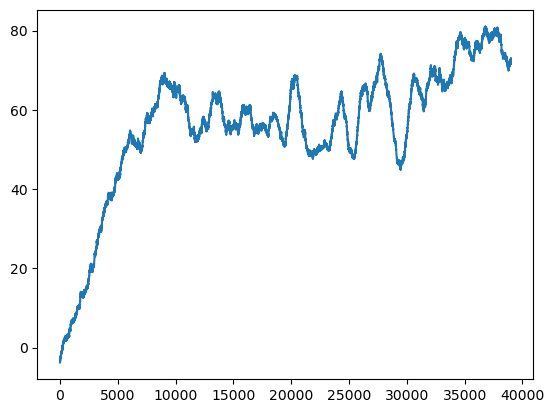

In [23]:
plt.plot(np.convolve(rewards,np.ones(1000)/1000,mode='valid'))

In [24]:
save_qtable(qtable, "qtable.npy")

In [30]:
def simulate_qtable(qtable):
    x0_odeint = get_random_initial_state()
    X_odeint = [x0_odeint]
    uvec = []

    state_c = x0_odeint
    state = discretizer.discretize_state(state_c)
    total_rewards = 0

    for step in range(max_steps):
        action = np.argmax(qtable[state])

        # convert action into force
        if action == 1:
            F = 10
        else:
            F = -10
            
        uvec.append(F)

        # Simulate the system
        x_odeint = odeint(cart_and_pole_odeint, state_c, t_odeint, args=(F, ))
        new_state_c = x_odeint[1]
        new_state = discretizer.discretize_state(new_state_c)
        X_odeint=np.append(X_odeint, [state_c], axis= 0)

        if discretizer.is_terminal_state(new_state):
            reward = -10
        else:
            reward = 1

        total_rewards =total_rewards + reward

        # Our new state is state
        state = new_state
        state_c = new_state_c

        # If done (if we're dead) : finish episode
        if discretizer.is_terminal_state(new_state):
            break
    
    print("Time:", np.arange(0.0, 10, time_step)[:len(uvec)][-1])
    time_sim=np.arange(0.0, 10+time_step, time_step)

    plt.rcParams['figure.figsize'] = [10, 15]
    fig, axs = plt.subplots(5)
    fig.subplots_adjust(hspace=0.5)

    axs[0].plot(np.arange(0.0, 10, time_step)[:len(uvec)], uvec, 'r', label='U(t)')
    axs[0].set_title("U")

    axs[1].plot(time_sim[:X_odeint[:,0].shape[0]], X_odeint[:,0], 'b')
    axs[1].set_title("theta(t)")

    axs[2].plot(time_sim[:X_odeint[:,1].shape[0]], X_odeint[:,1], 'b')
    axs[2].set_title("dot theta(t)")

    axs[3].plot(time_sim[:X_odeint[:,2].shape[0]], X_odeint[:,2], 'b')
    axs[3].set_title("p_c(t)")

    axs[4].plot(time_sim[:X_odeint[:,3].shape[0]], X_odeint[:,3], 'b')
    axs[4].set_title("dot p_c(t)")

Time: 3.66


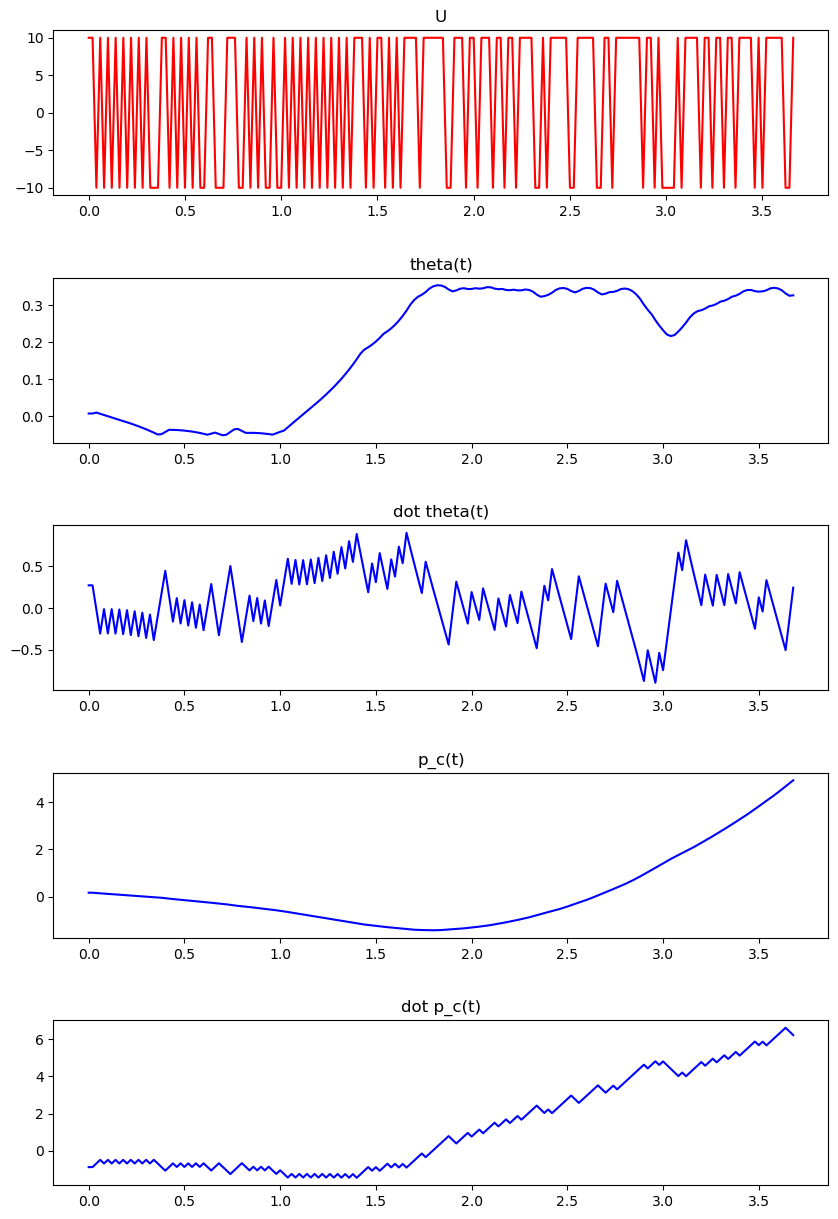

In [37]:
simulate_qtable(qtable)

7.    Copy and paste your Q-learning algorithm and apply the changes needed to convert it into a SARSA algorithm

SARSA stands for State-Action-Reward-State-Action.

SARSA works like following:
- To update the Qtable we use the following equation: $Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha ( R_{t+1} + \gamma Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t) )$

So for each iteration we need to know:
- $S_t$ and $A_t$ which are the current state and action
- $R_{t+1}$ which is the reward when performing $A_t$ being on $S_t$
- $S_{t+1}$ and $A_{t+1}$, which are the next state and action

In [27]:
qtable_sarsa = load_or_init_qtable("qtable_sarsa.npy")

In [28]:
rewards_sarsa = []
epsilon_decay = 10000

In [29]:
for episode in tqdm(range(total_episodes)):
    # Reset the environment
    episode_reward = 0
    state_c = get_random_initial_state()
    state = discretizer.discretize_state(state_c)
    
    action = episilon_greedy_policy(epsilon, qtable_sarsa, state)

    for step in range(max_steps):
        new_action = episilon_greedy_policy(epsilon, qtable_sarsa, state)
            
        # convert action into force
        if action == 1:
            F = 10
        else:
            F = -10

        # Simulate the system
        x_odeint = odeint(cart_and_pole_odeint, state_c, t_odeint, args=(F, ))
        new_state_c = x_odeint[1]
        new_state = discretizer.discretize_state(new_state_c)
        
        if discretizer.is_terminal_state(new_state):
            reward = -100
        else:
            reward = 1

        qtable_sarsa[state + (action,)] = qtable_sarsa[state + (action,)] + \
        learning_rate * (reward + gamma * qtable_sarsa[new_state + (new_action,)] - qtable_sarsa[state + (action,)])
        
        episode_reward += reward
        
        # Our new state is state
        state = new_state
        state_c = new_state_c
        action = new_action

        # If done (if we're dead) : finish episode
        if discretizer.is_terminal_state(new_state):
            break
        
    # Reduce epsilon (because we need less and less exploration)
    epsilon = min_epsilon + (max_epsilon - min_epsilon)*np.exp(-decay_rate*epsilon_decay)
    epsilon_decay += 1 
    rewards_sarsa.append(episode_reward)

    if episode % 5000 == 0:
        print(np.average(rewards[-5000:]))

print ("Score over time: " +  str(sum(rewards_sarsa)/total_episodes))
print("Epsilon:", epsilon)

SyntaxError: 'return' outside function (1884548469.py, line 1)

In [ ]:
save_qtable(qtable_sarsa, "qtable_sarsa.npy")

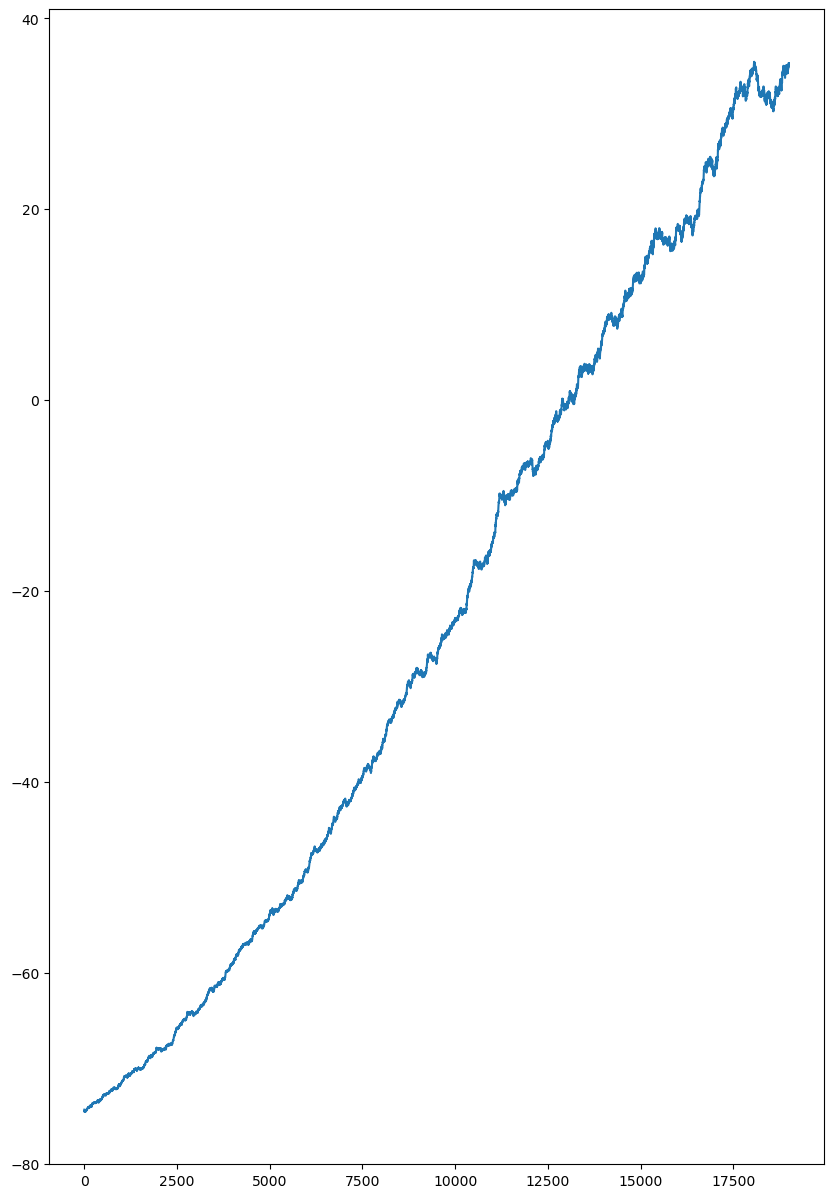

In [ ]:
plt.plot(np.convolve(rewards_sarsa,np.ones(1000)/1000,mode='valid'))

Time: 2.12


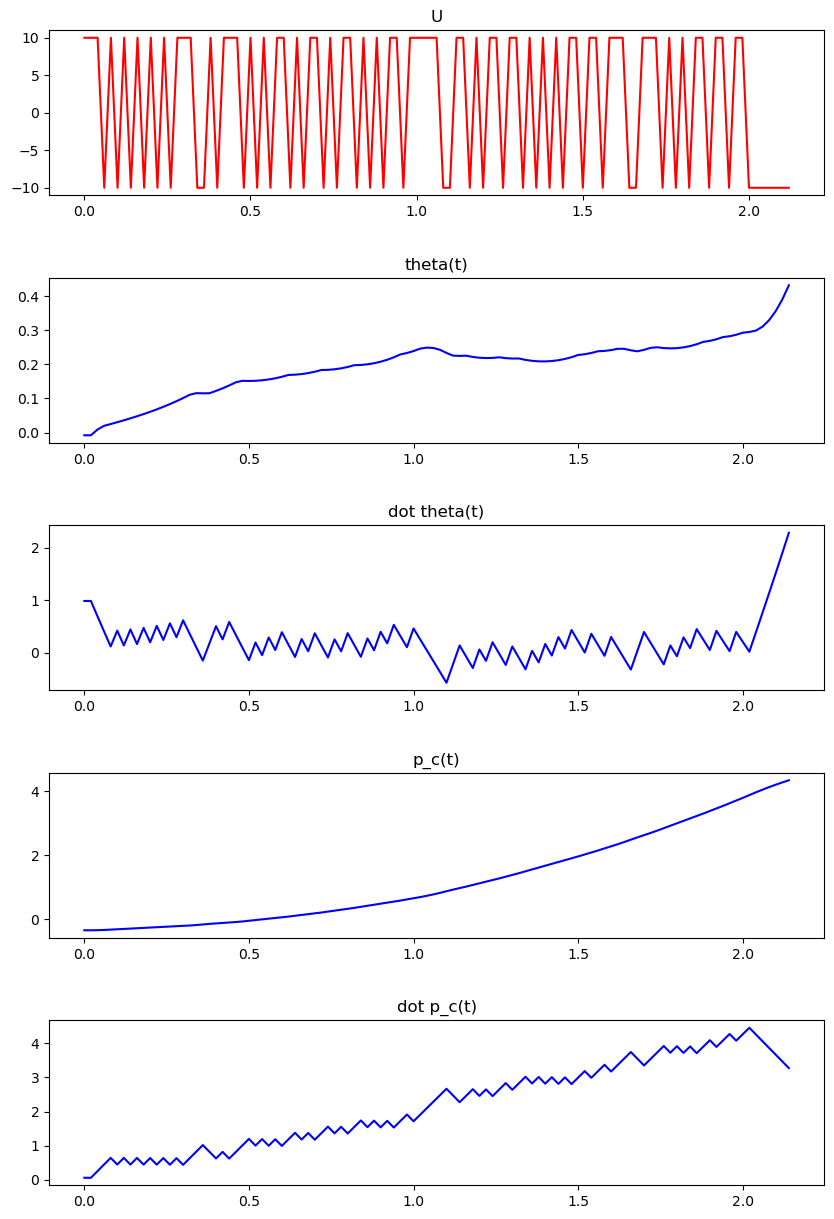

In [ ]:
simulate_qtable(qtable_sarsa)